1000


Text(0.5, 1.0, 'Trajectory for 10 Revolution(s)')

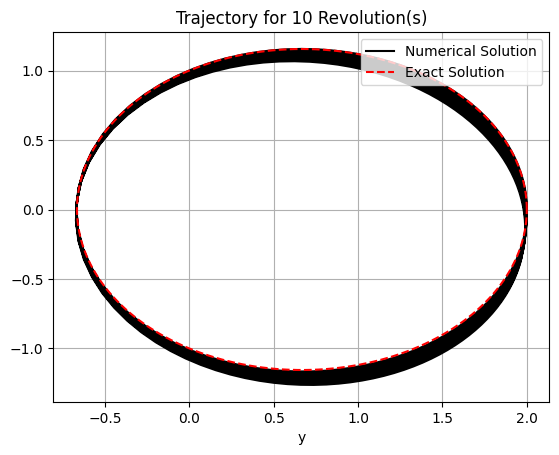

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

a = 4/3

Num_Rev = 10

T = 2 * np.pi * a**(3/2) 

h = 0.01 * T

def d_uv(p):
    u,v = p
    return np.array([u, v])

def d_xy(q):
    x,y = q
    return np.array([x*(x**2 + y**2)**(- 3/2), y*(x**2 + y**2)**(- 3/2)])

def update_p1(p,q):
    return p - (h/2) * d_xy(q)

def update_q(p,q):
    return q + h*d_uv(update_p1(p,q))

def update_p2(p,q):
    return update_p1(p,q) - (h/2) * d_xy(update_q(p,q))

def hamiltonian(p,q):
    return 0.5 * (np.dot(p,p)) - (1/np.sqrt(np.dot(q,q)))

q0 = [2, 0]

p0 = [0, 1/2]

q = [q0]
p = [p0]


energy = [hamiltonian(p0, q0)]
time = np.linspace(0, T * Num_Rev, int(np.round((T * Num_Rev)/h)))
#print((T * Num_Rev)/h)
for i in range(int(np.round(T/h))* Num_Rev-1):
    
    q_temp = update_q(p[i], q[i])
    p_temp = update_p2(p[i], q[i])
    energy.append(hamiltonian(p_temp, q_temp))
    q.append(q_temp)
    p.append(p_temp)
    

def positions(x):
    x1 = []
    x2 = []
    for element in x:
        x1.append(element[0])
        x2.append(element[1])
    return np.array(x1), np.array(x2)

print(len(q))  



plt.plot(*positions(q), color = "black", label = "Numerical Solution")
plt.grid(True)

eccentricity = 0.5
x_max = 2
x_min = -2/3

# center
x0 = (x_max + x_min) / 2
y0 = 0


a = (x_max - x_min) / 2


b = a * np.sqrt(1 - eccentricity**2)


t = np.linspace(0, 2*np.pi, 400)


x = x0 + a * np.cos(t)
y = y0 + b * np.sin(t)

plt.plot(x, y, color = "red", ls = "--", label = "Exact Solution")
plt.xlabel("x")
plt.xlabel("y")
plt.legend(loc = "upper right")
plt.title(f"Trajectory for {Num_Rev} Revolution(s)")
#plt.savefig("1period.svg")

#plt.plot(time, energy)
    

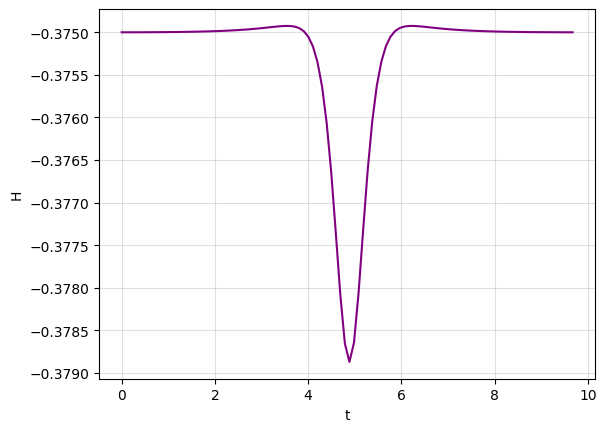

In [43]:
plt.plot(time, energy, color = "purple")
plt.xlabel("t")
plt.ylabel("H")
plt.grid(alpha = 0.4)
plt.savefig("energytime1.svg")

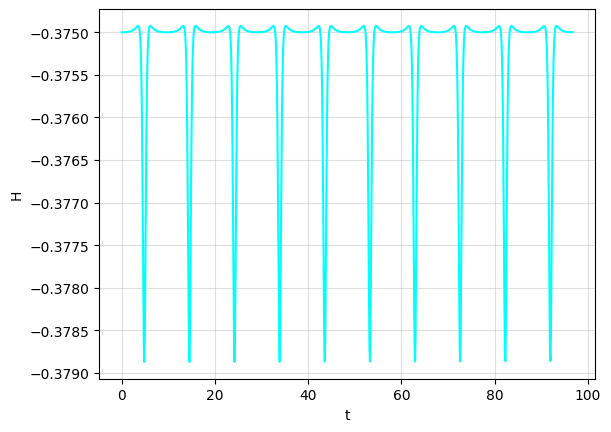

In [46]:
plt.plot(time, energy, color = "cyan")
plt.xlabel("t")
plt.ylabel("H")
plt.grid(alpha = 0.4)
plt.savefig("energytime10.svg")

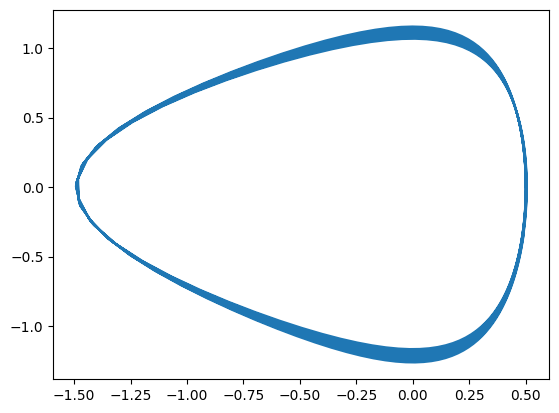

In [48]:
def firstpt(x,y, pos = 0):
    v1 = []
    v2 = []

    for i, j in zip(x,y):
        v1.append(i[pos])
        v2.append(j[pos])
    return v1, v2

plt.plot(*firstpt(p,q, pos = 1))